In [8]:
import os
import sys

root = "/tmp2/maitanha/vgu/cll_vlm/cll_vlm"

if root not in sys.path:
    sys.path.append(root)

import torch
import re
import csv
import random
import numpy as np
import pandas as pd
import yaml
import json
from argparse import ArgumentParser
from torch.utils.data import DataLoader
from tqdm import tqdm
import pdb
from dataset.cifar10 import CIFAR10Dataset
from dataset.cifar20 import CIFAR20Dataset, CIFAR100Dataset
from dataset.tiny200 import Tiny200Dataset
from dataset.caltech101 import Caltech101Dataset

from models.llava_classifier import LLaVAClassifier
from models.qwen_classifier import QWENClassifier
from models.clip_model import CLIPModel
from PIL import Image   

In [4]:
def load_config(config_path):
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config file '{config_path}' not found.")
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config

def collate_fn(batch):
    images, labels = zip(*batch)
    return list(images), list(labels)

def load_dataset(data_name):
    BASE_DIR = "/tmp2/maitanha/vgu/cll_vlm"
    DATA_DIR = os.path.join(BASE_DIR, "cll_vlm/data")

    data_root_path = os.path.join(DATA_DIR, data_name)

    if data_name == "cifar10":
        dataset = CIFAR10Dataset(
            root=data_root_path,
            train=True,
            transform=None
        )
    elif data_name == "cifar20":
        dataset = CIFAR20Dataset(
            root=data_root_path,
            train=True,
            transform=None
        )
    elif data_name == "cifar100":
        dataset = CIFAR100Dataset(
            root = data_root_path,
            train=True,
            transform=None
        )
        fine_classes_raw = dataset.get_fine_classes()
        fine_classes = [
            CIFAR100Dataset.preprocess_label(lbl)
            for lbl in fine_classes_raw
        ]
        coarse_classes = dataset.get_coarse_classes()
    elif data_name == "tiny200":
        dataset = Tiny200Dataset(
            root=data_root_path,
            train=True,
            transform=None
        )
    elif data_name == "caltech-101":
        dataset = Caltech101Dataset(
            root=data_root_path,
            train=True,
            transform=None
        )
    else:
        raise ValueError(f"Dataset '{data_name}' chưa được hỗ trợ trong hàm load_dataset.")
    
    return dataset

In [3]:
dataset = CIFAR100Dataset("/tmp2/maitanha/vgu/cll_vlm/cll_vlm/data/cifar100")
fine_classes_raw = dataset.get_fine_classes()
fine_classes = [
    CIFAR100Dataset.preprocess_label(lbl)
    for lbl in fine_classes_raw
]
coarse_classes = dataset.get_coarse_classes()

original_dataset, shuffled_dataset = dataset.get_shuffled_labels_dataset(seed=42)

In [5]:
dataset = load_dataset("tiny200/tiny-imagenet-200")
fine_classes = list(dataset.classes)

original_dataset, shuffled_dataset = dataset.get_shuffled_labels_dataset(seed=42)

ValueError: Dataset 'tiny200/tiny-imagenet-200' chưa được hỗ trợ trong hàm load_dataset.

In [9]:
dataset = load_dataset("caltech-101")
fine_classes_raw = dataset.classes
fine_classes = [
    dataset.preprocess_label(lbl)
    for lbl in fine_classes_raw
]

print(fine_classes)

original_dataset, shuffled_dataset = dataset.get_shuffled_labels_dataset(seed=42)

['faces', 'leopards', 'motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car side', 'ceiling fan', 'cellphone', 'chair', 'chandelier', 'cougar body', 'cougar face', 'crab', 'crayfish', 'crocodile', 'crocodile head', 'cup', 'dalmatian', 'dollar bill', 'dolphin', 'dragonfly', 'electric guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo head', 'garfield', 'gerenuk', 'gramophone', 'grand piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline skate', 'joshua tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea horse', 'snoopy', 'soccer ball', 'stapler', 'starfish',

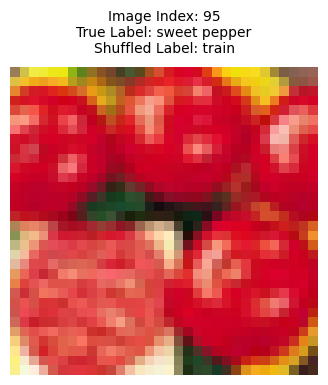

In [7]:
import matplotlib.pyplot as plt

def display_image(data, fine_classes, true_label_idx, shuffled_label_idx, img_idx):

    image, _ = data[img_idx]
    
    true_label = fine_classes[true_label_idx]
    shuffled_label = fine_classes[shuffled_label_idx]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    
    title_text = f"Image Index: {img_idx}\n"
    title_text += f"True Label: {true_label}\n"
    title_text += f"Shuffled Label: {shuffled_label}"
    
    plt.title(title_text, fontsize=10, pad=10)
    plt.axis('off')
    plt.show()

img_idx = 95

_, true_label_idx = original_dataset[img_idx]
_, shuffled_label_idx = shuffled_dataset[img_idx]

display_image(shuffled_dataset, fine_classes, true_label_idx, shuffled_label_idx, img_idx)

In [47]:
count = 0
for c in fine_classes:
    count += 1

print(fine_classes_raw)
print(fine_classes)
print(count)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

In [48]:
import json
import os
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

JSON_DIR = Path("/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/cifar100")
# JSON_DIR = Path("/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/round2/cifar100")
json_files = sorted(JSON_DIR.glob("*.json"))
print(f"Found {len(json_files)} JSON files:")
for f in json_files:
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

Found 58 JSON files:
  llava_cifar100_multi_label_lbs100_prompt_v2.json  (12.6 MB)
  llava_cifar100_multi_label_lbs10_prompt_v2.json  (60.6 MB)
  llava_cifar100_multi_label_lbs20_prompt_v2.json  (36.3 MB)
  llava_cifar100_multi_label_lbs20_test_prompt_v2.json  (0.0 MB)
  llava_cifar100_multi_label_lbs20_test_prompt_v2_raw_answers.json  (0.0 MB)
  llava_cifar100_multi_label_lbs50_prompt_v2.json  (19.0 MB)
  llava_cifar100_multi_label_lbs5_prompt_v2.json  (16.9 MB)
  qwen3_2b_cifar100_multi_label_lbs10.json  (133.1 MB)
  qwen3_2b_cifar100_multi_label_lbs100_prompt_v1.json  (15.5 MB)
  qwen3_2b_cifar100_multi_label_lbs100_prompt_v2.json  (15.5 MB)
  qwen3_2b_cifar100_multi_label_lbs10_prompt_v1.json  (140.3 MB)
  qwen3_2b_cifar100_multi_label_lbs10_prompt_v2.json  (138.8 MB)
  qwen3_2b_cifar100_multi_label_lbs20.json  (58.7 MB)
  qwen3_2b_cifar100_multi_label_lbs20_prompt_v1.json  (67.8 MB)
  qwen3_2b_cifar100_multi_label_lbs20_prompt_v2.json  (70.7 MB)
  qwen3_2b_cifar100_multi_label_lbs

## Analyze Multi-Label Results

Với mỗi sample, mô hình trả về một **list** các label dự đoán (multi-label). Ta kiểm tra xem `true_label` có nằm trong list đó không.

- **Correct**: `true_label` xuất hiện trong `answer` list
- **Accuracy**: tỉ lệ sample đúng

In [49]:
def analyze_file(json_path):
    """Analyze a multi-label JSON result file.
    
    Returns a dict with:
      - total: total samples
      - correct: samples where true_label is in answer list
      - empty_answer: samples with None/empty answer
      - accuracy: correct / total
      - avg_answer_len: average number of labels in answer
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    total = len(data)
    correct = 0
    empty_answer = 0
    answer_lengths = []
    
    for item in data:
        true_label = str(item.get('true_label', '')).strip().lower()
        answer = item.get('answer')
        
        if not answer:  # None or empty list
            empty_answer += 1
            continue
        
        # Normalize answer list to lowercase strings
        answer_normalized = [str(a).strip().lower() for a in answer]
        answer_lengths.append(len(answer_normalized))
        
        if true_label in answer_normalized:
            correct += 1
    
    accuracy = correct / total if total > 0 else 0.0
    avg_len = sum(answer_lengths) / len(answer_lengths) if answer_lengths else 0.0
    
    return {
        'total': total,
        'correct': correct,
        'empty_answer': empty_answer,
        'accuracy': accuracy,
        'avg_answer_len': avg_len,
    }

print('analyze_file() function defined.')

analyze_file() function defined.


In [50]:
results = []
failed_files = []

for json_path in json_files:
    name = json_path.stem  # filename without extension
    print(f"Processing {json_path.name} ...", end=' ', flush=True)

    try:
        stats = analyze_file(json_path)
        stats['file'] = name
        results.append(stats)

        print(
            f"done. Total={stats['total']:,}, Correct={stats['correct']:,}, "
            f"Accuracy={stats['accuracy']:.4f}, Avg answer len={stats['avg_answer_len']:.2f}"
        )

    except Exception as e:
        failed_files.append(json_path.name)
        print(f"ERROR -> skipped. Reason: {e}")

print("\n✅ Done!")

if failed_files:
    print("\nFiles with errors:")
    for fname in failed_files:
        print(f"- {fname}")

Processing llava_cifar100_multi_label_lbs100_prompt_v2.json ... done. Total=50,000, Correct=3,748, Accuracy=0.0750, Avg answer len=1.00
Processing llava_cifar100_multi_label_lbs10_prompt_v2.json ... 

done. Total=50,000, Correct=14,677, Accuracy=0.2935, Avg answer len=1.00
Processing llava_cifar100_multi_label_lbs20_prompt_v2.json ... done. Total=50,000, Correct=11,214, Accuracy=0.2243, Avg answer len=1.00
Processing llava_cifar100_multi_label_lbs20_test_prompt_v2.json ... done. Total=8, Correct=5, Accuracy=0.6250, Avg answer len=1.00
Processing llava_cifar100_multi_label_lbs20_test_prompt_v2_raw_answers.json ... ERROR -> skipped. Reason: 'str' object has no attribute 'get'
Processing llava_cifar100_multi_label_lbs50_prompt_v2.json ... done. Total=50,000, Correct=4,953, Accuracy=0.0991, Avg answer len=1.00
Processing llava_cifar100_multi_label_lbs5_prompt_v2.json ... ERROR -> skipped. Reason: Expecting ',' delimiter: line 290298 column 2 (char 16865073)
Processing qwen3_2b_cifar100_multi_label_lbs10.json ... done. Total=50,000, Correct=46,449, Accuracy=0.9290, Avg answer len=7.64
Processing qwen3_2b_cifar100_multi_label_lbs100_prompt_v1.json ... done. Total=50,000, Correct=39,158, A

In [51]:
df = pd.DataFrame(results, columns=['file', 'total', 'correct', 'empty_answer', 'accuracy', 'avg_answer_len'])
df = df.set_index('file')
df['accuracy_pct'] = (df['accuracy'] * 100).round(2)

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
print("=" * 80)
print("MULTI-LABEL ACCURACY SUMMARY")
print("=" * 80)
df[['total', 'correct', 'empty_answer', 'accuracy_pct', 'avg_answer_len']]

MULTI-LABEL ACCURACY SUMMARY


,total,correct,empty_answer,accuracy_pct,avg_answer_len
file,,,,,
llava_cifar100_multi_label_lbs100_prompt_v2,50000,3748,45713,7.5000,1.0000
llava_cifar100_multi_label_lbs10_prompt_v2,50000,14677,30939,29.3500,1.0000
llava_cifar100_multi_label_lbs20_prompt_v2,50000,11214,36390,22.4300,1.0000
llava_cifar100_multi_label_lbs20_test_prompt_v2,8,5,3,62.5000,1.0000
llava_cifar100_multi_label_lbs50_prompt_v2,50000,4953,44218,9.9100,1.0000
qwen3_2b_cifar100_multi_label_lbs10,50000,46449,6,92.9000,7.6364
qwen3_2b_cifar100_multi_label_lbs100_prompt_v1,50000,39158,43,78.3200,1.0176
qwen3_2b_cifar100_multi_label_lbs100_prompt_v2,50000,39158,43,78.3200,1.0176
qwen3_2b_cifar100_multi_label_lbs10_prompt_v1,50000,39472,22,78.9400,1.0349


## Accuracy vs Label Batch Size (per model)

In [52]:
# Parse model name and label batch size from filename
# Format: {model}_cifar100_multi_label_lbs{N}.json
import re

df_plot = df.copy().reset_index()
df_plot['model'] = df_plot['file'].str.extract(r'^(.+)_cifar100_multi_label_lbs\d+')
df_plot['lbs'] = df_plot['file'].str.extract(r'_lbs(\d+)').astype(float)
df_plot = df_plot.dropna(subset=['model', 'lbs'])
df_plot['lbs'] = df_plot['lbs'].astype(int)

print(df_plot[['file', 'model', 'lbs', 'accuracy', 'avg_answer_len']].sort_values(['model', 'lbs']).to_string(index=False))

                                              file    model  lbs  accuracy  avg_answer_len
        llava_cifar100_multi_label_lbs10_prompt_v2    llava   10    0.2935          1.0000
        llava_cifar100_multi_label_lbs20_prompt_v2    llava   20    0.2243          1.0000
   llava_cifar100_multi_label_lbs20_test_prompt_v2    llava   20    0.6250          1.0000
        llava_cifar100_multi_label_lbs50_prompt_v2    llava   50    0.0991          1.0000
       llava_cifar100_multi_label_lbs100_prompt_v2    llava  100    0.0750          1.0000
                    qwen_cifar100_multi_label_lbs5     qwen    5    0.9047         16.7440
          qwen_cifar100_multi_label_lbs5_prompt_v1     qwen    5    0.6571          1.0000
          qwen_cifar100_multi_label_lbs5_prompt_v2     qwen    5    0.6561          1.0000
                   qwen_cifar100_multi_label_lbs10     qwen   10    0.8118          3.7051
         qwen_cifar100_multi_label_lbs10_prompt_v1     qwen   10    0.6624          1.0042

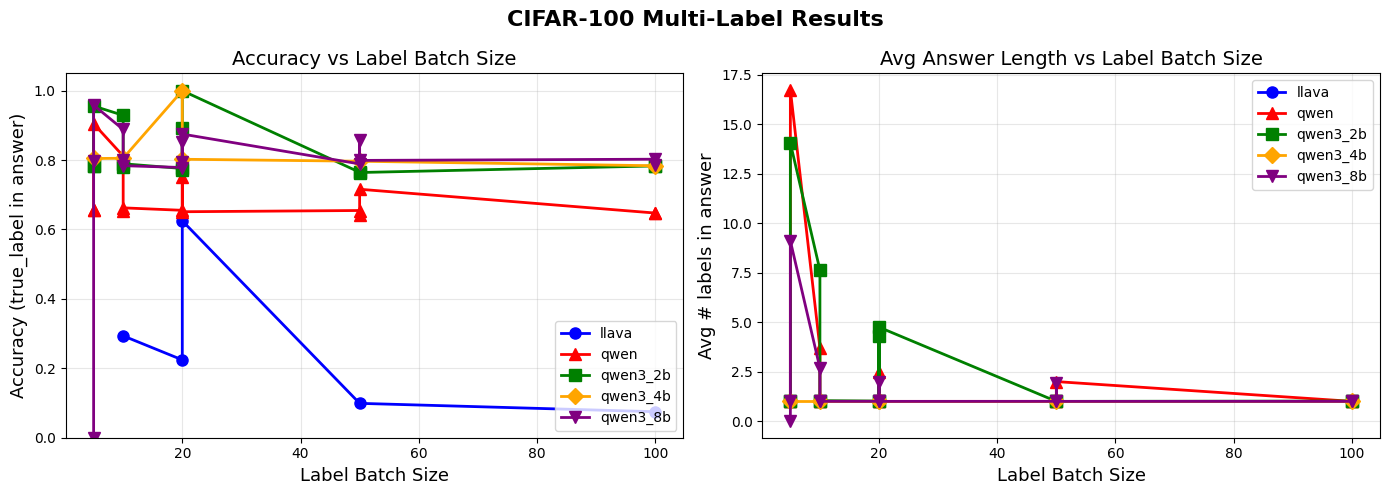

Plot saved.


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CIFAR-100 Multi-Label Results', fontsize=16, fontweight='bold')

models = df_plot['model'].unique()
colors = ['blue', 'red', 'green', 'orange', 'purple']
markers = ['o', '^', 's', 'D', 'v']

# Plot 1: Accuracy vs LBS
ax1 = axes[0]
for i, model in enumerate(sorted(models)):
    sub = df_plot[df_plot['model'] == model].sort_values('lbs')
    ax1.plot(sub['lbs'], sub['accuracy'], marker=markers[i % len(markers)],
             color=colors[i % len(colors)], linewidth=2, markersize=8, label=model)
ax1.set_xlabel('Label Batch Size', fontsize=13)
ax1.set_ylabel('Accuracy (true_label in answer)', fontsize=13)
ax1.set_title('Accuracy vs Label Batch Size', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# Plot 2: Avg Answer Length vs LBS
ax2 = axes[1]
for i, model in enumerate(sorted(models)):
    sub = df_plot[df_plot['model'] == model].sort_values('lbs')
    ax2.plot(sub['lbs'], sub['avg_answer_len'], marker=markers[i % len(markers)],
             color=colors[i % len(colors)], linewidth=2, markersize=8, label=model)
ax2.set_xlabel('Label Batch Size', fontsize=13)
ax2.set_ylabel('Avg # labels in answer', fontsize=13)
ax2.set_title('Avg Answer Length vs Label Batch Size', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multi_label_accuracy_cifar100.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Quick Single-File Inspection

In [54]:
# # Quickly inspect one specific file
# target_file = JSON_DIR / "qwen3_2b_cifar100_multi_label_lbs20_round2.json"

# with open(target_file) as f:
#     data = json.load(f)

# total = len(data)
# correct_items = []
# wrong_items = []
# empty_items = []

# for item in data:
#     true_label = str(item.get('true_label', '')).strip().lower()
#     answer = item.get('answer')
    
#     if not answer:
#         empty_items.append(item)
#         continue
    
#     answer_norm = [str(a).strip().lower() for a in answer]
#     if true_label in answer_norm:
#         correct_items.append(item)
#     else:
#         wrong_items.append(item)

# accuracy = len(correct_items) / total
# print(f"File: {target_file.name}")
# print(f"Total samples  : {total:,}")
# print(f"Correct        : {len(correct_items):,}")
# print(f"Wrong          : {len(wrong_items):,}")
# print(f"Empty answer   : {len(empty_items):,}")
# print(f"Accuracy       : {accuracy:.4f} ({accuracy*100:.2f}%)")
# print()
# print("--- Sample WRONG predictions (first 5) ---")
# for item in wrong_items[:5]:
#     print(f"  img_idx={item['img_idx']}, true_label='{item['true_label']}', answer={item['answer']}")

### Plot Qwen - CIFAR100

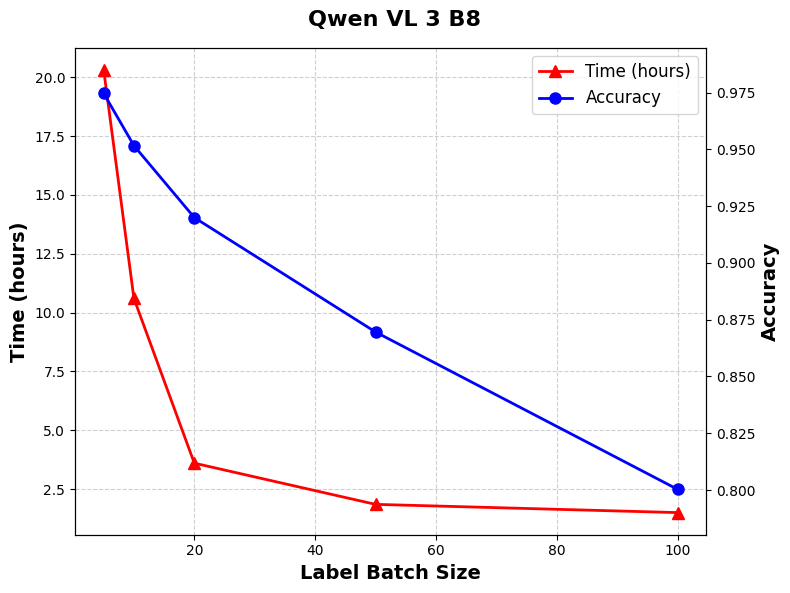

In [55]:
import matplotlib.pyplot as plt

label_batch = [5, 10, 20, 50, 100]


# Qwen 3 2b
time_hours = [20.3, 10.6, 3.6, 1.85, 1.5]
accuracy = [0.9747, 0.9517, 0.92, 0.8696, 0.8003]

# time_hours = [32.3, 15.3, 8, 3.75, 2.3]
# accuracy = [0.9332, 0.9207, 0.8890, 0.8571, 0.8142]

fig, ax1 = plt.subplots(figsize=(8,6))
fig.suptitle("Qwen VL 3 B8", fontsize=16, fontweight='bold')

# ----- Y trái: Time (hours) -----
line1 = ax1.plot(
    label_batch,
    time_hours,
    color='red',
    marker='^',
    linewidth=2,
    markersize=8,
    label='Time (hours)'
)

ax1.set_xlabel("Label Batch Size", fontsize=14, fontweight='bold')
ax1.set_ylabel("Time (hours)", fontsize=14, fontweight='bold')
ax1.tick_params(axis='y')

# ----- Y phải: Accuracy -----
ax2 = ax1.twinx()

line2 = ax2.plot(
    label_batch,
    accuracy,
    color='blue',
    marker='o',
    linewidth=2,
    markersize=8,
    label='Accuracy'
)

ax2.set_ylabel("Accuracy", fontsize=14, fontweight='bold')
ax2.set_ylim(min(accuracy)-0.02, max(accuracy)+0.02)

# ----- Legend chung -----
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=12)

ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [56]:
def load_json_file(json_path):
    json_path = Path(json_path)
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

def get_cifar100_label_set(data_root="/tmp2/maitanha/vgu/cll_vlm/cll_vlm/data/cifar100"):
    """
    Returns
    -------
    fine_classes : list[str]
        Ordered CIFAR-100 fine labels from dataset
    fine_class_set : set[str]
        Valid label set
    fine_class_to_idx : dict[str, int]
        Label -> original position in fine_classes
    """
    dataset = CIFAR100Dataset(data_root)
    fine_classes_raw = dataset.get_fine_classes()
    fine_classes = [
        CIFAR100Dataset.preprocess_label(lbl)
        for lbl in fine_classes_raw
    ]
    fine_class_to_idx = {label: i for i, label in enumerate(fine_classes)}
    return fine_classes, set(fine_classes), fine_class_to_idx

In [57]:
def analyze_answer_labels(records, valid_label_set):
    overall_label_counts = Counter()
    invalid_label_counts = Counter()
    position_label_counts = defaultdict(Counter)

    per_sample_invalid_details = []
    per_sample_duplicate_details = []

    total_answer_labels = 0

    for item in records:
        img_idx = item.get("img_idx")
        true_label = item.get("true_label")
        shuffled_label = item.get("shuffled_label")
        answers = item.get("answer", [])

        overall_label_counts.update(answers)
        total_answer_labels += len(answers)

        for pos, label in enumerate(answers):
            position_label_counts[pos][label] += 1

        invalid_labels = [label for label in answers if label not in valid_label_set]
        if invalid_labels:
            invalid_label_counts.update(invalid_labels)
            per_sample_invalid_details.append({
                "img_idx": img_idx,
                "true_label": true_label,
                "shuffled_label": shuffled_label,
                "invalid_labels": invalid_labels,
                "answer": answers,
            })

        local_counter = Counter(answers)
        duplicated_labels = {label: cnt for label, cnt in local_counter.items() if cnt > 1}
        if duplicated_labels:
            per_sample_duplicate_details.append({
                "img_idx": img_idx,
                "true_label": true_label,
                "shuffled_label": shuffled_label,
                "duplicated_labels": duplicated_labels,
                "answer": answers,
            })

    return {
        "total_samples": len(records),
        "total_answer_labels": total_answer_labels,
        "overall_label_counts": overall_label_counts,
        "invalid_label_counts": invalid_label_counts,
        "position_label_counts": position_label_counts,
        "per_sample_invalid_details": per_sample_invalid_details,
        "per_sample_duplicate_details": per_sample_duplicate_details,
    }

In [58]:
def ordered_label_count_df(all_labels, observed_counter):
    """
    Return counts in the exact order of all_labels.
    """
    rows = []
    for idx, label in enumerate(all_labels):
        rows.append({
            "label_index": idx,
            "label": label,
            "count": observed_counter.get(label, 0)
        })
    return pd.DataFrame(rows)

In [59]:
def complete_label_count_df(all_labels, observed_counter):
    """
    Return a DataFrame for all labels in all_labels,
    including labels with zero count.
    """
    rows = []
    for label in all_labels:
        rows.append({
            "label": label,
            "count": observed_counter.get(label, 0)
        })

    return pd.DataFrame(rows).sort_values(
        ["count", "label"], ascending=[False, True]
    ).reset_index(drop=True)

In [60]:
def invalid_details_to_df(invalid_details):
    rows = []
    for item in invalid_details:
        for label in item["invalid_labels"]:
            rows.append({
                "img_idx": item["img_idx"],
                "true_label": item["true_label"],
                "shuffled_label": item["shuffled_label"],
                "invalid_label": label,
                "answer": item["answer"],
            })

    if not rows:
        return pd.DataFrame(columns=["img_idx", "true_label", "shuffled_label", "invalid_label", "answer"])

    return pd.DataFrame(rows)

In [61]:
def duplicate_details_to_df(duplicate_details):
    rows = []
    for item in duplicate_details:
        for label, count in item["duplicated_labels"].items():
            rows.append({
                "img_idx": item["img_idx"],
                "true_label": item["true_label"],
                "shuffled_label": item["shuffled_label"],
                "duplicated_label": label,
                "count_in_answer": count,
                "answer": item["answer"],
            })

    if not rows:
        return pd.DataFrame(columns=["img_idx", "true_label", "shuffled_label", "duplicated_label", "count_in_answer", "answer"])

    return pd.DataFrame(rows)

In [62]:
def ordered_position_count_df(all_labels, position_label_counts):
    """
    Return dataframe with:
        position, label_index, label, count
    preserving all_labels order inside each position.
    """
    rows = []
    positions = sorted(position_label_counts.keys())

    for pos in positions:
        counter = position_label_counts[pos]
        for idx, label in enumerate(all_labels):
            rows.append({
                "position": pos,
                "label_index": idx,
                "label": label,
                "count": counter.get(label, 0)
            })

    return pd.DataFrame(rows)

In [63]:
from collections import defaultdict

def run_label_analysis(json_path, valid_label_set, all_labels):
    records = load_json_file(json_path)
    summary = analyze_answer_labels(records, valid_label_set)

    overall_ordered_df = ordered_label_count_df(
        all_labels,
        summary["overall_label_counts"]
    )

    invalid_count_df = pd.DataFrame(
        [{"label": k, "count": v} for k, v in summary["invalid_label_counts"].items()]
    )
    if len(invalid_count_df) == 0:
        invalid_count_df = pd.DataFrame(columns=["label", "count"])
    else:
        invalid_count_df = invalid_count_df.sort_values(["count", "label"], ascending=[False, True]).reset_index(drop=True)

    invalid_detail_df = invalid_details_to_df(summary["per_sample_invalid_details"])
    duplicate_detail_df = duplicate_details_to_df(summary["per_sample_duplicate_details"])

    position_ordered_df = ordered_position_count_df(
        all_labels,
        summary["position_label_counts"]
    )

    return {
        "records": records,
        "summary": summary,
        "overall_ordered_df": overall_ordered_df,
        "invalid_count_df": invalid_count_df,
        "invalid_detail_df": invalid_detail_df,
        "duplicate_detail_df": duplicate_detail_df,
        "position_ordered_df": position_ordered_df,
    }

In [13]:
import json
import re
from pathlib import Path
from collections import Counter

def advanced_analysis(json_path, fine_classes):
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        return {"error": str(e)}
        
    fine_classes_set = set([c.lower() for c in fine_classes])
    
    # Rút trích chỉ số LBS từ tên file (LBS 20 -> 20)
    match_lbs = re.search(r'lbs(\d+)', Path(json_path).name)
    lbs_value = int(match_lbs.group(1)) if match_lbs else 10
    
    # CIFAR100 có 100 nhãn
    TOTAL_LABELS = 100 
    max_allowed_candidates = TOTAL_LABELS // lbs_value 
    
    out_of_set_labels = set()
    missed_samples = []
    position_counts_when_correct = Counter()
    position_counts_total = Counter()
    oversized_candidates = []

    # NEW: answer chứa > 1 label
    multi_answer_samples = []
    
    for item in data:
        if not isinstance(item, dict):
            continue
        
        img_idx = item.get('img_idx')
        true_label = str(item.get('true_label', '')).strip().lower()
        candidate = item.get('candidate_answer', [])
        answer = item.get('answer', [])
        
        if isinstance(candidate, str):
            candidate = [candidate]
        if isinstance(answer, str):
            answer = [answer]
            
        candidate = [str(c).strip().lower() for c in candidate if str(c).strip()]
        answer = [str(a).strip().lower() for a in answer if str(a).strip()]
        
        # KIỂM TRA OVERSIZED CANDIDATE
        if len(candidate) > max_allowed_candidates:
            oversized_candidates.append({
                'img_idx': img_idx,
                'true_label': true_label,
                'candidate_length': len(candidate),
                'candidate_list': candidate
            })

        # NEW: KIỂM TRA ANSWER CÓ > 1 LABEL
        if len(answer) > 1:
            multi_answer_samples.append({
                'img_idx': img_idx,
                'true_label': true_label,
                'answer_length': len(answer),
                'answer_list': answer
            })
        
        # 1. Label set check (Tìm nhãn lạ)
        for c in candidate:
            if c and c not in fine_classes_set:
                out_of_set_labels.add(c)
        for a in answer:
            if a and a != "no" and a not in fine_classes_set:
                out_of_set_labels.add(a)
                
        # 2. Thu thập MISSED SAMPLES
        if true_label in candidate and true_label not in answer:
            missed_samples.append({
                'img_idx': img_idx,
                'true_label': true_label,
                'candidates': candidate,
                'final_choice': answer
            })
            
        # 3. Position analysis
        if true_label in candidate:
            pos = candidate.index(true_label) + 1
            position_counts_total[pos] += 1
            if true_label in answer:
                position_counts_when_correct[pos] += 1
                
    return {
        'file': Path(json_path).name,
        'lbs': lbs_value,
        'limit': max_allowed_candidates,
        'out_of_set_labels': list(out_of_set_labels),
        'missed_data': missed_samples,
        'pos_counts_correct': dict(position_counts_when_correct),
        'pos_counts_total': dict(position_counts_total),
        'oversized_samples': oversized_candidates,

        # NEW
        'multi_answer_samples': multi_answer_samples,
        'multi_answer_count': len(multi_answer_samples),

        'error': None
    }

# --- CHẠY KIỂM TRA HOÀN CHỈNH ---
# JSON_DIR = Path("/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/cifar100")
# json_files = sorted(JSON_DIR.glob("*prompt_v1.json"))

JSON_DIR = Path("/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/caltech101")
json_files = sorted(JSON_DIR.glob("*.json"))

for jf in json_files:
    res = advanced_analysis(jf, fine_classes)
    
    if res.get('error'):
        print(f"\n⚠️ SKIP: {jf.name} ({res['error']})")
        continue

    print(f"\n{'='*90}")
    print(f"📊 File: {res['file']} | LBS: {res['lbs']} | Ngưỡng Batch: {res['limit']}")
    print(f"{'='*90}")
    
    # 1. Label set check (IN RA NHÃN LẠ)
    if len(res['out_of_set_labels']) > 0:
        print(f"⚠️ CẢNH BÁO: Phả hiện nhãn lạ (NGOÀI label set): {res['out_of_set_labels']}")
    else:
        print("✅ Tất cả nhãn (Candidate/Answer) đều nằm trong label set.")
        
    # 2. Print over-labeled Candidate answers
    if len(res['oversized_samples']) > 0:
        print(f"⚠️ Có {len(res['oversized_samples'])} samples có số nhãn > {res['limit']} batches (Candidate answers).")
        print("   👉 Chi tiết oversized samples:")
        for smp in res['oversized_samples']:
            print(f"      [IMG {smp['img_idx']:5d}] True: '{smp['true_label']}' | "
                f"candidate_length: {smp['candidate_length']}")
            # print(f"                   | Candidates: {smp['candidate_list']}")
            print(f"      {'-'*35}")
    else:
        print(f"✅ Độ dài candidate OK (<= {res['limit']}).")

    # NEW: Check answer có > 1 label
    multi_answer_count = res['multi_answer_count']
    if multi_answer_count > 0:
        print(f"⚠️ Có {multi_answer_count} samples mà 'answer' chứa nhiều hơn 1 label.")
        print("   👉 Img idx có multi-answer:")
        print("      ", [smp['img_idx'] for smp in res['multi_answer_samples']])

        print("   👉 5 mẫu tiêu biểu:")
        for smp in res['multi_answer_samples'][:5]:
            print(f"      [IMG {smp['img_idx']:5d}] True: '{smp['true_label']}' | "
                  f"answer_length: {smp['answer_length']}")
            print(f"                   | Answer: {smp['answer_list']}")
            print(f"      {'-'*35}")
    else:
        print("✅ Tất cả 'answer' đều có tối đa 1 label.")

    # 3. Missed Samples check (IN RA CHI TIẾT)
    total_missed = len(res['missed_data'])
    print(f"❌ Số mẫu 'Missed' (Nằm trong candidate nhưng chọn sai): {total_missed}")
    if total_missed > 0:
        print(f"   👉 5 mẫu sai tiêu biểu:")
        for smp in res['missed_data'][:5]: # In 5 cái tiêu biểu
            print(f"      [IMG {smp['img_idx']:5d}] True: '{smp['true_label']}'\n"
                  f"                   | Candidates: {smp['candidates']}\n"
                  f"                   | VLM Choice: {smp['final_choice']}")
            print(f"      {'-'*35}")
            
    # 4. Position accuracy check (IN RA ACC THEO VỊ TRÍ)
    print(f"\n📍 Accuracy by Position:")
    all_positions = sorted(res['pos_counts_total'].keys())
    for pos in all_positions:
        total = res['pos_counts_total'][pos]
        correct = res['pos_counts_correct'].get(pos, 0)
        acc = (correct / total * 100) if total > 0 else 0
        print(f"   Pos {pos:2d}: {acc:6.2f}% ({correct:5d}/{total:5d})")



📊 File: qwen3_4b_caltech101_multi_label_lbs20_prompt_v1_modified_final_prompt.json | LBS: 20 | Ngưỡng Batch: 5
⚠️ CẢNH BÁO: Phả hiện nhãn lạ (NGOÀI label set): ['puppies', 'lot', 'star', 'seahorse', 'emperor']
✅ Độ dài candidate OK (<= 5).
✅ Tất cả 'answer' đều có tối đa 1 label.
❌ Số mẫu 'Missed' (Nằm trong candidate nhưng chọn sai): 248
   👉 5 mẫu sai tiêu biểu:
      [IMG    64] True: 'faces'
                   | Candidates: ['faces', 'chair', 'laptop', 'windsor chair']
                   | VLM Choice: ['chair']
      -----------------------------------
      [IMG    79] True: 'faces'
                   | Candidates: ['faces', 'chair', 'windsor chair']
                   | VLM Choice: ['chair']
      -----------------------------------
      [IMG    94] True: 'faces'
                   | Candidates: ['faces', 'chair', 'lamp', 'windsor chair']
                   | VLM Choice: ['chair']
      -----------------------------------
      [IMG   134] True: 'faces'
                   | Can

In [14]:
import json
import re
import pandas as pd
from pathlib import Path
from collections import Counter
from IPython.display import display

def full_analysis_v7(json_path, fine_classes):
    """Phân tích toàn diện và trả về dictionary."""
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        return {"error": str(e), "file": Path(json_path).name}
        
    total = len(data)
    correct_final = 0    
    correct_candidate = 0 
    empty_answer = 0
    ans_lengths = []
    
    # Store position data for current file
    pos_counts_total = Counter()
    pos_counts_correct = Counter()
    
    for item in data:
        if not isinstance(item, dict): continue
        true_label = str(item.get('true_label', '')).strip().lower()
        candidate = item.get('candidate_answer', [])
        answer = item.get('answer', [])
        
        if isinstance(candidate, str): candidate = [candidate]
        if isinstance(answer, str): answer = [answer]
        candidate = [str(c).strip().lower() for c in candidate]
        answer = [str(a).strip().lower() for a in answer]
        
        ans_lengths.append(len(answer))
        if not answer or (len(answer) == 1 and answer[0] == ""):
            empty_answer += 1

        if true_label in candidate:
            correct_candidate += 1
            pos = candidate.index(true_label) + 1
            pos_counts_total[pos] += 1
            if true_label in answer:
                correct_final += 1
                pos_counts_correct[pos] += 1

    return {
        'file': Path(json_path).name,
        'total': total,
        'c_count': correct_candidate,
        'f_count': correct_final,
        'candidate_acc': (correct_candidate / total * 100) if total > 0 else 0,
        'final_acc': (correct_final / total * 100) if total > 0 else 0,
        'missed': (correct_candidate - correct_final),
        'empty_ans': empty_answer,
        'avg_ans_len': (sum(ans_lengths) / total) if total > 0 else 0,
        'pos_data': {'correct': dict(pos_counts_correct), 'total': dict(pos_counts_total)},
        'error': None
    }

# --- THỰC THI VÀ HIỂN THỊ ---
# JSON_DIR = Path("/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/cifar100")
# json_files = sorted(JSON_DIR.glob("*prompt_v1.json"))

JSON_DIR = Path("/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/caltech101")
json_files = sorted(JSON_DIR.glob("*.json"))

summary_list = []
all_results = [] # Lưu toàn bộ object res để in chi tiết ở dưới

for jf in json_files:
    res = full_analysis_v7(jf, fine_classes)
    if res.get('error'):
        print(f"⚠️ SKIP: {res['file']} - {res['error']}")
        continue
    
    all_results.append(res)
    summary_list.append({
        'File Name': res['file'],
        'Total': f"{res['total']:,}",
        'Cand Correct': f"{res['c_count']:,}",
        'Cand Acc (%)': f"{res['candidate_acc']:.2f}%",
        'Final Correct': f"{res['f_count']:,}",
        'Final Acc (%)': f"{res['final_acc']:.2f}%",
        'Missed (Cand-Final)': f"{res['missed']:,}",
        'Empty Ans': res['empty_ans'],
        'Avg Ans Len': f"{res['avg_ans_len']:.2f}"
    })

# HIỂN THỊ BẢNG TỔNG HỢP
df_summary = pd.DataFrame(summary_list)
print("\n" + "="*50)
print("📊 BẢNG TỔNG HỢP MULTI-LABEL ANALYSIS")
print("="*50)
display(df_summary)

# HIỂN THỊ POSITION ACCURACY CHI TIẾT CHO TỪNG FILE
for res in all_results:
    print(f"\n📍 Position Accuracy Breakdown: {res['file']}")
    print("-" * 65)
    all_pos = sorted(res['pos_data']['total'].keys())
    for p in all_pos:
        total_p = res['pos_data']['total'][p]
        correct_p = res['pos_data']['correct'].get(p, 0)
        acc_p = (correct_p / total_p * 100) if total_p > 0 else 0
        print(f"Position {p:2d}: {acc_p:6.2f}% ({correct_p:5d}/{total_p:5d} samples)")



📊 BẢNG TỔNG HỢP MULTI-LABEL ANALYSIS


,File Name,Total,Cand Correct,Cand Acc (%),Final Correct,Final Acc (%),Missed (Cand-Final),Empty Ans,Avg Ans Len
0,qwen3_4b_caltech101_multi_label_lbs20_prompt_v...,"8,242","8,100",98.28%,"7,852",95.27%,248,18,1.00



📍 Position Accuracy Breakdown: qwen3_4b_caltech101_multi_label_lbs20_prompt_v1_modified_final_prompt.json
-----------------------------------------------------------------
Position  1:  97.42% ( 5028/ 5161 samples)
Position  2:  95.53% ( 2117/ 2216 samples)
Position  3:  98.06% (  607/  619 samples)
Position  4:  96.08% (   98/  102 samples)
Position  5: 100.00% (    2/    2 samples)



📊 REPORT CHO FILE: qwen3_2b_cifar100_multi_label_lbs10_prompt_v1.json


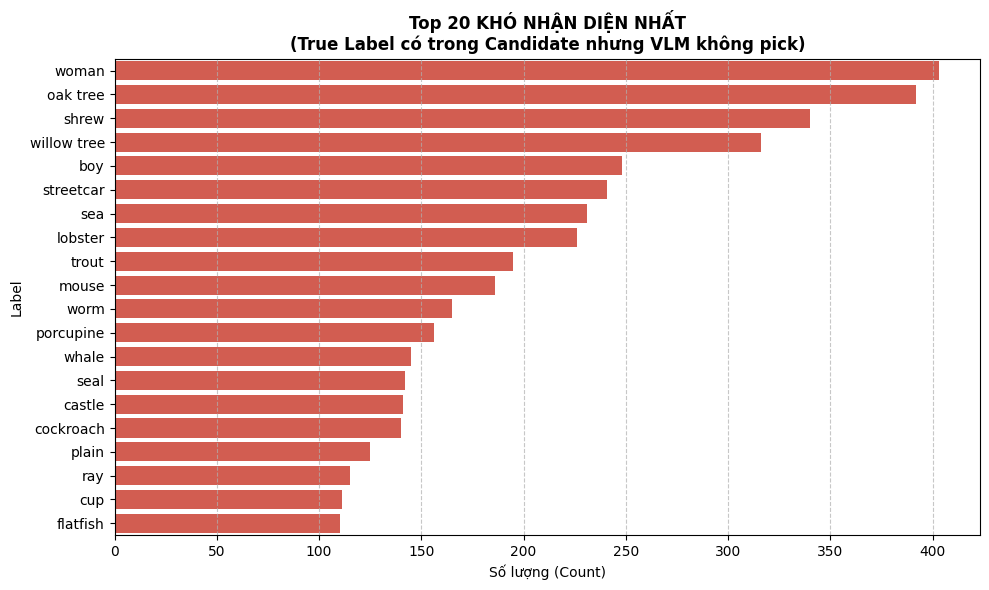

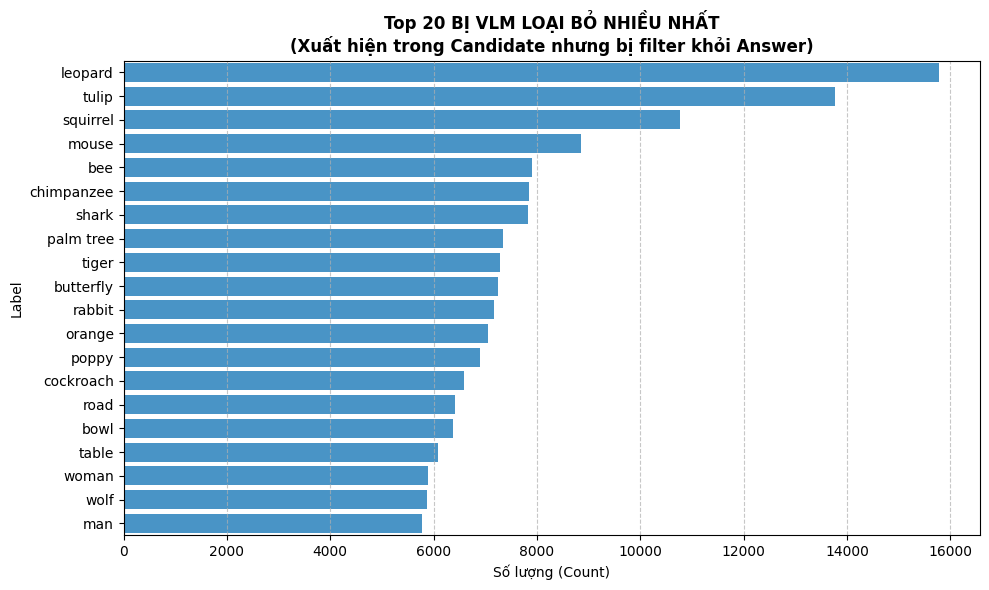

In [66]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from IPython.display import display

def plot_dropped_labels(json_path, top_n=20):
    """
    Đếm và plot các labels nằm trong candidate nhưng không được chọn làm final answer.
    """
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Lỗi khi đọc file {json_path}: {e}")
        return

    missed_true_labels = Counter() # true_label nằm trong cand nhưng không nằm trong ans
    all_dropped_labels = Counter() # Bất kỳ label nào nằm trong cand nhưng không nằm trong ans

    for item in data:
        if not isinstance(item, dict): 
            continue
            
        true_label = str(item.get('true_label', '')).strip().lower()
        candidate = item.get('candidate_answer', [])
        answer = item.get('answer', [])
        
        if isinstance(candidate, str): candidate = [candidate]
        if isinstance(answer, str): answer = [answer]
        candidate = [str(c).strip().lower() for c in candidate]
        answer = [str(a).strip().lower() for a in answer]

        # 1. Check Missed True Labels (True label có trong candidate nhưng VLM lại không pick)
        if true_label in candidate and true_label not in answer:
            missed_true_labels[true_label] += 1

        # 2. Check All Dropped Labels (Nhãn nằm trong cand mà bị loại khỏi answer)
        for cand in candidate:
            if cand not in answer:
                all_dropped_labels[cand] += 1

    # Hàm vẽ biểu đồ phụ
    def plot_counter(counter_data, title, color):
        if not counter_data:
            print(f"Không có dữ liệu cho biểu đồ: {title}")
            return
            
        # Lấy Top N
        common = counter_data.most_common(top_n)
        labels = [x[0] for x in common]
        counts = [x[1] for x in common]
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=counts, y=labels, color=color)
        plt.title(title, fontweight='bold')
        plt.xlabel("Số lượng (Count)")
        plt.ylabel("Label")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    print(f"\n{'='*60}")
    print(f"📊 REPORT CHO FILE: {Path(json_path).name}")
    print(f"{'='*60}")
    
    # Vẽ biểu đồ True Labels bị miss
    plot_counter(
        missed_true_labels, 
        f"Top {top_n} KHÓ NHẬN DIỆN NHẤT\n(True Label có trong Candidate nhưng VLM không pick)", 
        color="#e74c3c"
    )
    
    # Vẽ biểu đồ All Labels bị drop
    plot_counter(
        all_dropped_labels, 
        f"Top {top_n} BỊ VLM LOẠI BỎ NHIỀU NHẤT\n(Xuất hiện trong Candidate nhưng bị filter khỏi Answer)", 
        color="#3498db"
    )


# Nếu không chạy cell trước đó, có thể hardcode một path:
hardcoded_path = "/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/cifar100/qwen3_2b_cifar100_multi_label_lbs10_prompt_v1.json"
plot_dropped_labels(hardcoded_path, top_n=20)

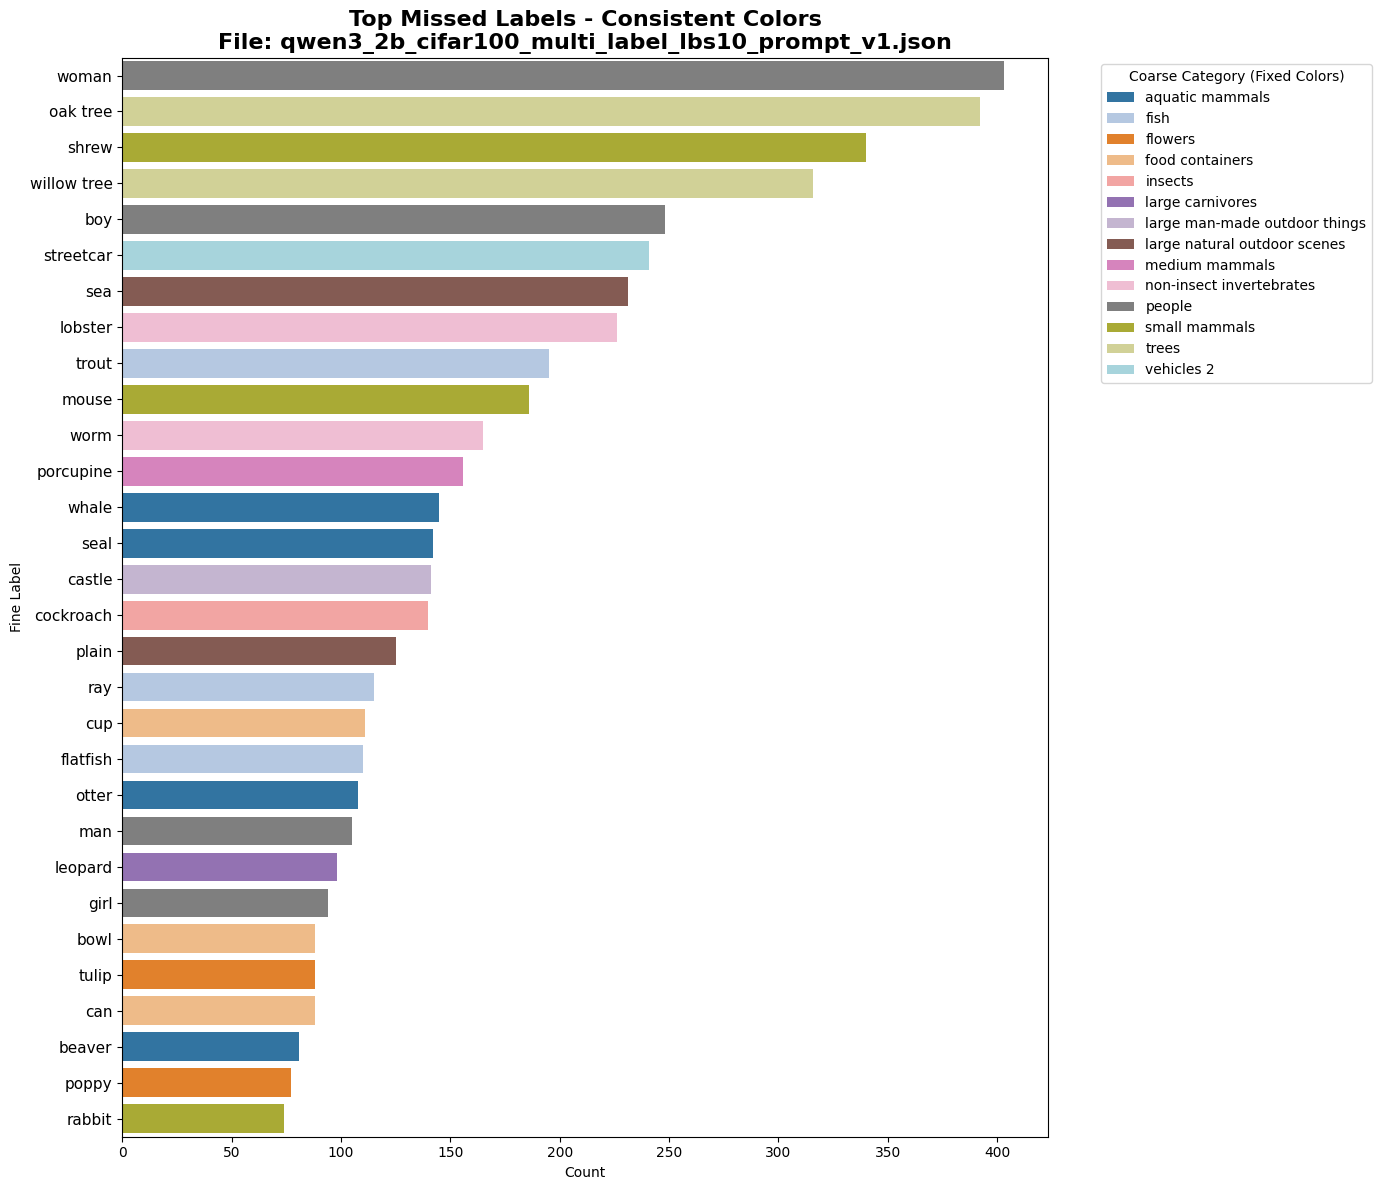

In [67]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# --- 1. SỬA ĐƯỜNG DẪN CỦA BẠN TẠI ĐÂY ---
target_json_path = "/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/cifar100/qwen3_2b_cifar100_multi_label_lbs10_prompt_v1.json"

# --- 2. DANH SÁCH 100 FINE LABELS (CIFAR-100) ---
fine_classes = [
    'apple', 'aquarium fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak tree', 'orange', 'orchid', 'otter', 'palm tree', 'pear', 'pickup truck', 'pine tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow tree', 'wolf', 'woman', 'worm'
]

# --- 3. LOGIC MAPPING COARSE LABELS ---
COARSE_LABEL_NAMES = [
    'aquatic mammals', 'fish', 'flowers', 'food containers', 'fruit and vegetables',
    'household electrical devices', 'household furniture', 'insects', 'large carnivores',
    'large man-made outdoor things', 'large natural outdoor scenes', 'large omnivores and herbivores',
    'medium mammals', 'non-insect invertebrates', 'people', 'reptiles', 'small mammals', 'trees',
    'vehicles 1', 'vehicles 2'
]

FINE_TO_COARSE_IDX = {
    0: 4, 1: 1, 2: 14, 3: 8, 4: 0, 5: 6, 6: 7, 7: 7, 8: 18, 9: 3, 10: 3, 11: 14, 12: 9, 13: 18, 14: 7, 15: 11, 16: 3, 17: 9, 18: 7, 19: 11, 20: 6, 21: 11, 22: 5, 23: 10, 24: 7, 25: 6, 26: 13, 27: 15, 28: 3, 29: 15, 30: 0, 31: 11, 32: 1, 33: 10, 34: 12, 35: 14, 36: 16, 37: 9, 38: 11, 39: 5, 40: 5, 41: 19, 42: 8, 43: 8, 44: 15, 45: 13, 46: 14, 47: 17, 48: 18, 49: 10, 50: 16, 51: 4, 52: 17, 53: 4, 54: 2, 55: 0, 56: 17, 57: 4, 58: 18, 59: 17, 60: 10, 61: 3, 62: 2, 63: 12, 64: 12, 65: 16, 66: 12, 67: 1, 68: 9, 69: 19, 70: 2, 71: 10, 72: 0, 73: 1, 74: 16, 75: 12, 76: 9, 77: 13, 78: 15, 79: 13, 80: 16, 81: 19, 82: 2, 83: 4, 84: 6, 85: 19, 86: 5, 87: 5, 88: 8, 89: 19, 90: 18, 91: 1, 92: 2, 93: 15, 94: 6, 95: 0, 96: 17, 97: 8, 98: 14, 99: 13
}

label_to_coarse = {fine_classes[f_idx]: COARSE_LABEL_NAMES[c_idx] for f_idx, c_idx in FINE_TO_COARSE_IDX.items()}

# --- 4. ĐỌC DỮ LIỆU VÀ TÍNH TOÁN ---
missed_true_labels = Counter()
try:
    with open(target_json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    for item in data:
        t_label = str(item.get('true_label', '')).strip().lower()
        cand = [str(c).strip().lower() for c in item.get('candidate_answer', [])]
        ans = [str(a).strip().lower() for a in item.get('answer', [])]
        if t_label in cand and t_label not in ans:
            missed_true_labels[t_label] += 1
except Exception as e:
    print(f"Lỗi: {e}")

# --- 1. TẠO COLOR MAP CỐ ĐỊNH CHO 20 NHÓM (CHỈ CHẠY 1 LẦN) ---
palette_20 = plt.cm.tab20.colors # Lấy 20 màu tiêu chuẩn
coarse_color_map = {name: palette_20[i] for i, name in enumerate(COARSE_LABEL_NAMES)}
# --- 2. CẬP NHẬT HÀM VẼ (DÙNG PALETTE CỐ ĐỊNH) ---
def plot_top_missed(counter_data, title, top_n=30):
    if not counter_data:
        print("Không tìm thấy dữ liệu.")
        return
        
    common = counter_data.most_common(top_n)
    df = pd.DataFrame(common, columns=['Fine Label', 'Count'])
    df['Coarse Category'] = df['Fine Label'].map(lambda x: label_to_coarse.get(x, 'Unknown'))
    
    # Lọc ra danh sách các nhóm xuất hiện trong Top này để vẽ Legend chính xác
    categories_in_plot = df['Coarse Category'].unique()
    
    plt.figure(figsize=(14, 12))
    
    # Dùng palette=coarse_color_map để màu luôn khớp với Category đó
    sns.barplot(
        data=df, 
        x='Count', 
        y='Fine Label', 
        hue='Coarse Category', 
        dodge=False, 
        palette=coarse_color_map, # Sử dụng map màu cố định
        hue_order=sorted(categories_in_plot) # Sắp xếp legend cho gọn
    )
    
    plt.tick_params(axis='y', labelsize=11)
    plt.title(title, fontweight='bold', fontsize=16)
    plt.legend(title='Coarse Category (Fixed Colors)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()
# --- 3. CHẠY VẼ ---
plot_top_missed(missed_true_labels, f"Top Missed Labels - Consistent Colors\nFile: {Path(target_json_path).name}")


In [68]:
from collections import defaultdict, Counter
import pandas as pd

def analyze_specific_misses(json_path, top_n_missed=5):
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Lỗi: {e}")
        return

    # Lưu trữ: {true_label: Counter(các nhãn bị chọn thay thế)}
    confusion_map = defaultdict(Counter)
    missed_counts = Counter()

    for item in data:
        t_label = str(item.get('true_label', '')).strip().lower()
        cand = [str(c).strip().lower() for c in item.get('candidate_answer', [])]
        ans = [str(a).strip().lower() for a in item.get('answer', [])]
        
        # Nếu True Label có trong Candidate nhưng KHÔNG có trong Answer (Missed case)
        if t_label in cand and t_label not in ans:
            missed_counts[t_label] += 1
            for chosen in ans:
                if chosen != "" and chosen != "no":
                    confusion_map[t_label][chosen] += 1

    # Lấy Top N nhãn bị miss nhiều nhất
    top_missed_labels = [lbl for lbl, count in missed_counts.most_common(top_n_missed)]

    print(f"\n{'='*75}")
    print(f"🕵️ CHI TIẾT CÁC NHÃN KHIẾN VLM NHẦM LẪN (TOP {top_n_missed} MISSED LABELS)")
    print(f"File: {Path(json_path).name}")
    print(f"{'='*75}")

    for lbl in top_missed_labels:
        total_missed = missed_counts[lbl]
        confusions = confusion_map[lbl].most_common(5) # Top 5 nhãn gây nhiễu cho nhãn này
        
        print(f"\n📍 TRƯỜNG HỢP: [{lbl.upper()}] (Bị bỏ lỡ {total_missed} lần)")
        print(f"   Thay vì chọn {lbl}, VLM thường chọn nhầm sang:")
        
        if not confusions:
            print(f"   --> ❗ (VLM không chọn bất cứ nhãn nào khác - Empty Answer)")
        else:
            for i, (mistake, count) in enumerate(confusions, 1):
                p = (count / total_missed) * 100
                coarse = label_to_coarse.get(mistake, "Unknown")
                print(f"   {i}. {mistake.ljust(15)} : {count} lần ({p:.1f}%) -> Nhóm: {coarse}")

# --- CHẠY PHÂN TÍCH CHI TIẾT ---
# Bạn có thể chỉnh top_n_missed lên 10 nếu muốn xem nhiều hơn
analyze_specific_misses(target_json_path, top_n_missed=5)



🕵️ CHI TIẾT CÁC NHÃN KHIẾN VLM NHẦM LẪN (TOP 5 MISSED LABELS)
File: qwen3_2b_cifar100_multi_label_lbs10_prompt_v1.json

📍 TRƯỜNG HỢP: [WOMAN] (Bị bỏ lỡ 403 lần)
   Thay vì chọn woman, VLM thường chọn nhầm sang:
   1. girl            : 395 lần (98.0%) -> Nhóm: people
   2. man             : 4 lần (1.0%) -> Nhóm: people
   3. baby            : 2 lần (0.5%) -> Nhóm: people
   4. boy             : 2 lần (0.5%) -> Nhóm: people
   5. table           : 1 lần (0.2%) -> Nhóm: household furniture

📍 TRƯỜNG HỢP: [OAK TREE] (Bị bỏ lỡ 392 lần)
   Thay vì chọn oak tree, VLM thường chọn nhầm sang:
   1. maple tree      : 320 lần (81.6%) -> Nhóm: trees
   2. forest          : 44 lần (11.2%) -> Nhóm: large natural outdoor scenes
   3. road            : 7 lần (1.8%) -> Nhóm: large man-made outdoor things
   4. cloud           : 4 lần (1.0%) -> Nhóm: large natural outdoor scenes
   5. willow tree     : 3 lần (0.8%) -> Nhóm: trees

📍 TRƯỜNG HỢP: [SHREW] (Bị bỏ lỡ 340 lần)
   Thay vì chọn shrew, VLM thườn

In [69]:
def plot_label_counts_in_dataset_order(overall_ordered_df, figsize=(22, 6), title=None):
    """
    Plot counts in the exact order of fine_classes.
    X-axis = label index in dataset order
    """
    if overall_ordered_df.empty:
        print("overall_ordered_df is empty.")
        return

    plt.figure(figsize=figsize)
    plt.bar(overall_ordered_df["label_index"], overall_ordered_df["count"])
    plt.xlabel("Label index in fine_classes order")
    plt.ylabel("Count")
    plt.title(title or "Label frequency in answers (dataset order)")
    plt.tight_layout()
    plt.show()

In [70]:
def plot_label_counts_with_names_in_dataset_order(overall_ordered_df, figsize=(24, 8), title=None):
    if overall_ordered_df.empty:
        print("overall_ordered_df is empty.")
        return

    plt.figure(figsize=figsize)
    plt.bar(overall_ordered_df["label"], overall_ordered_df["count"])
    plt.xticks(rotation=90, fontsize=18)
    plt.xlabel("Label (dataset order)")
    plt.ylabel("Count")
    plt.title(title or "Label frequency in answers (dataset order)", fontsize=50)
    plt.tight_layout()
    plt.show()

In [71]:
def plot_position_counts_in_dataset_order(position_ordered_df, position=0, figsize=(22, 6), title=None):
    """
    Plot counts for one answer position in exact fine_classes order.
    """
    df_pos = position_ordered_df[position_ordered_df["position"] == position].copy()

    if df_pos.empty:
        print(f"No data for position {position}")
        return

    plt.figure(figsize=figsize)
    plt.bar(df_pos["label_index"], df_pos["count"])
    plt.xlabel("Label index in fine_classes order")
    plt.ylabel("Count")
    plt.title(title or f"Label frequency at answer position {position} (dataset order)")
    plt.tight_layout()
    plt.show()

In [72]:
def plot_label_position_heatmap_in_dataset_order(position_ordered_df, all_labels, figsize=(14, 18)):
    """
    Heatmap:
        y-axis = labels in exact dataset order
        x-axis = answer position
    """
    if position_ordered_df.empty:
        print("position_ordered_df is empty.")
        return None

    pivot = position_ordered_df.pivot(
        index="label",
        columns="position",
        values="count"
    ).fillna(0)

    # enforce exact dataset order
    pivot = pivot.reindex(all_labels)

    plt.figure(figsize=figsize)
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="Count")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Answer Position")
    plt.ylabel("Label (dataset order)")
    plt.title("Heatmap of label frequency across answer positions (dataset order)")
    plt.tight_layout()
    plt.show()

    return pivot

In [73]:
# json_path = "/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/cifar100/qwen3_2b_cifar100_multi_label_lbs20.json"
json_path = "/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/cifar100/qwen3_2b_cifar100_multi_label_lbs10_prompt_v1.json"

fine_classes, fine_class_set, fine_class_to_idx = get_cifar100_label_set()

analysis = run_label_analysis(
    json_path=json_path,
    valid_label_set=fine_class_set,
    all_labels=fine_classes
)

In [74]:
print("Total samples:", analysis["summary"]["total_samples"])
print("Total answer labels:", analysis["summary"]["total_answer_labels"])
print("Number of invalid labels found:", len(analysis["invalid_count_df"]))
print("Number of samples with duplicated labels in answer:", len(analysis["duplicate_detail_df"]))

Total samples: 50000
Total answer labels: 51723
Number of invalid labels found: 2
Number of samples with duplicated labels in answer: 0


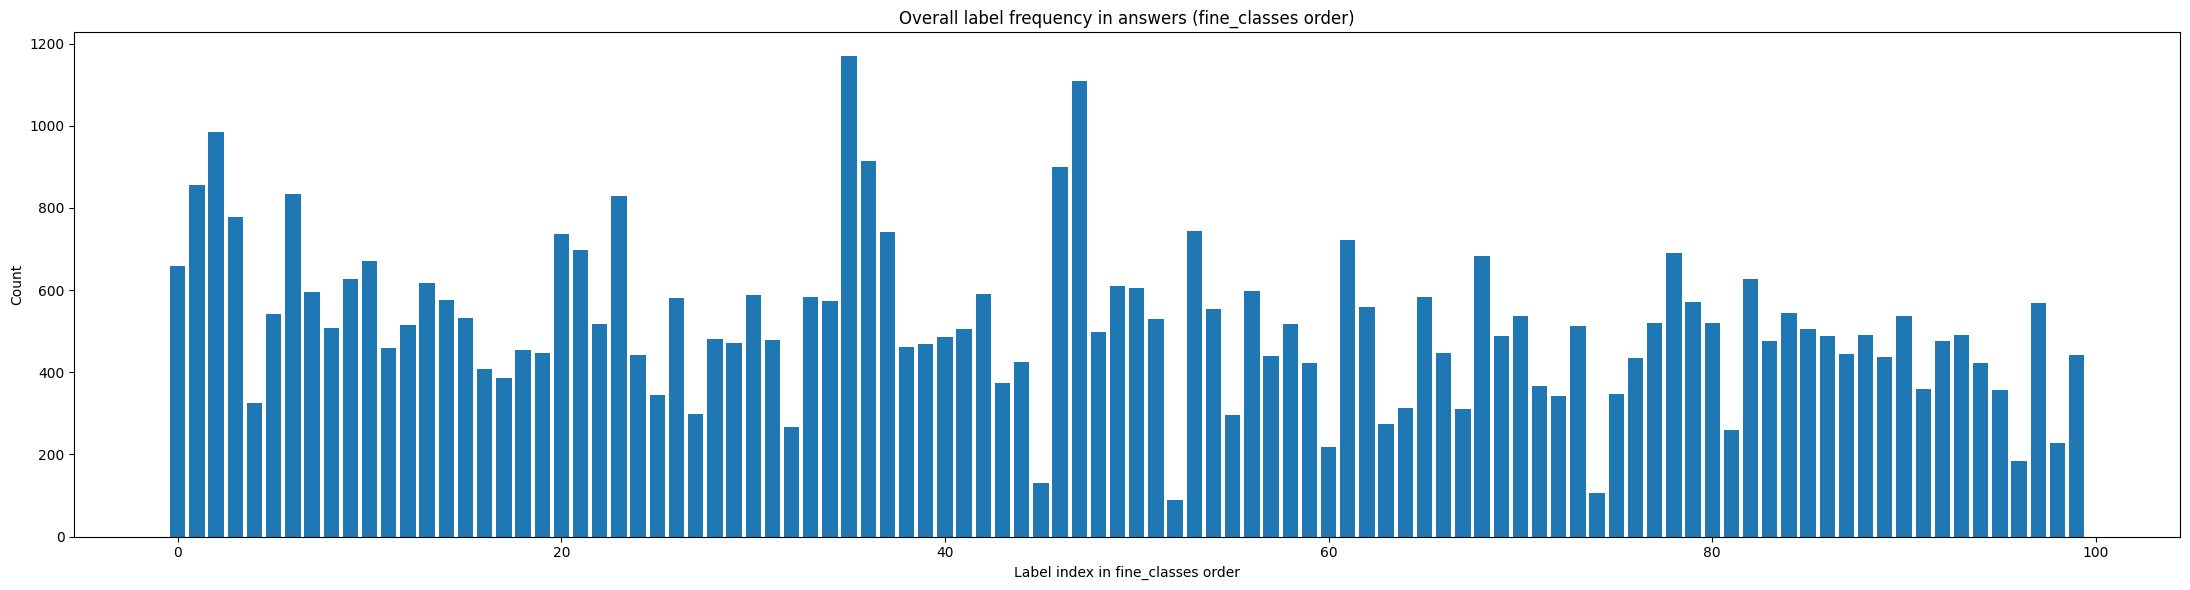

In [75]:
plot_label_counts_in_dataset_order(
    analysis["overall_ordered_df"],
    figsize=(22, 6),
    title="Overall label frequency in answers (fine_classes order)"
)

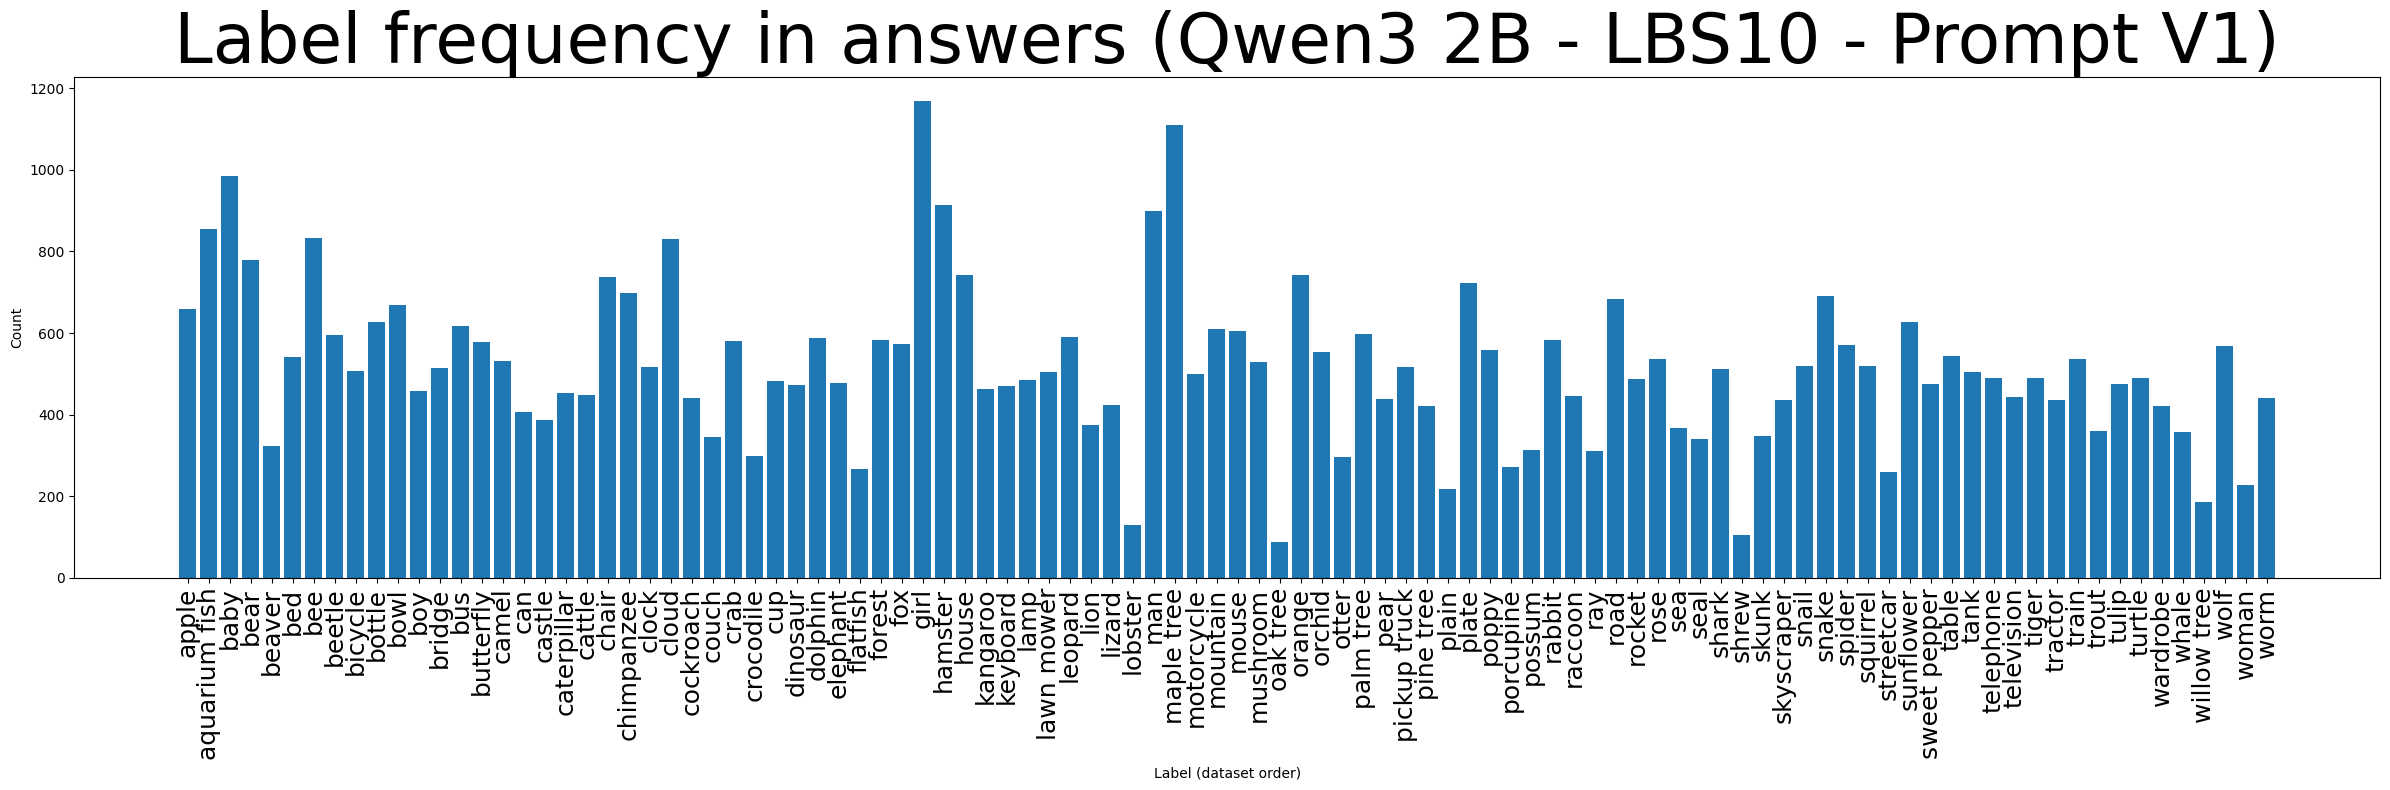

In [76]:
ax = plot_label_counts_with_names_in_dataset_order(
    analysis["overall_ordered_df"],
    figsize=(24, 8),
    title="Label frequency in answers (Qwen3 2B - LBS10 - Prompt V1)"
)

# Analyze prompt 3 / 4

In [4]:
import json
import re
import pandas as pd
from pathlib import Path
from collections import Counter
from IPython.display import display

def full_analysis_v7(json_path, fine_classes):
    """Phân tích toàn diện và trả về dictionary."""
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        return {"error": str(e), "file": Path(json_path).name}
        
    total = len(data)
    correct_final = 0    
    correct_candidate = 0 
    empty_answer = 0
    ans_lengths = []
    
    # Store position data for current file
    pos_counts_total = Counter()
    pos_counts_correct = Counter()
    
    for item in data:
        if not isinstance(item, dict): continue
        true_label = str(item.get('true_label', '')).strip().lower()
        candidate = item.get('candidate_answer', [])
        answer = item.get('new_answer', [])
        
        if isinstance(candidate, str): candidate = [candidate]
        if isinstance(answer, str): answer = [answer]
        candidate = [str(c).strip().lower() for c in candidate]
        answer = [str(a).strip().lower() for a in answer]
        
        ans_lengths.append(len(answer))
        if not answer or (len(answer) == 1 and answer[0] == ""):
            empty_answer += 1

        if true_label in candidate:
            correct_candidate += 1
            pos = candidate.index(true_label) + 1
            pos_counts_total[pos] += 1
            if true_label in answer:
                correct_final += 1
                pos_counts_correct[pos] += 1

    return {
        'file': Path(json_path).name,
        'total': total,
        'c_count': correct_candidate,
        'f_count': correct_final,
        'candidate_acc': (correct_candidate / total * 100) if total > 0 else 0,
        'final_acc': (correct_final / total * 100) if total > 0 else 0,
        'missed': (correct_candidate - correct_final),
        'empty_ans': empty_answer,
        'avg_ans_len': (sum(ans_lengths) / total) if total > 0 else 0,
        'pos_data': {'correct': dict(pos_counts_correct), 'total': dict(pos_counts_total)},
        'error': None
    }

# --- THỰC THI VÀ HIỂN THỊ ---
JSON_DIR = Path("/tmp2/maitanha/vgu/cll_vlm/cll_vlm/results/baseline3/baseline3/cifar100")
json_files = sorted(JSON_DIR.glob("*.json"))

summary_list = []
all_results = [] # Lưu toàn bộ object res để in chi tiết ở dưới

for jf in json_files:
    res = full_analysis_v7(jf, fine_classes)
    if res.get('error'):
        print(f"⚠️ SKIP: {res['file']} - {res['error']}")
        continue
    
    all_results.append(res)
    summary_list.append({
        'File Name': res['file'],
        'Total': f"{res['total']:,}",
        'Cand Correct': f"{res['c_count']:,}",
        'Cand Acc (%)': f"{res['candidate_acc']:.2f}%",
        'Final Correct': f"{res['f_count']:,}",
        'Final Acc (%)': f"{res['final_acc']:.2f}%",
        'Missed (Cand-Final)': f"{res['missed']:,}",
        'Empty/NO Ans': res['empty_ans'],
        'Avg Ans Len': f"{res['avg_ans_len']:.2f}"
    })

# HIỂN THỊ BẢNG TỔNG HỢP
df_summary = pd.DataFrame(summary_list)
print("\n" + "="*50)
print("📊 BASELINE 3 - PROMPT V3/V4 ANALYSIS")
print("="*50)
display(df_summary)

# HIỂN THỊ POSITION ACCURACY CHI TIẾT CHO TỪNG FILE
for res in all_results:
    print(f"\n📍 Position Accuracy Breakdown: {res['file']}")
    print("-" * 65)
    all_pos = sorted(res['pos_data']['total'].keys())
    for p in all_pos:
        total_p = res['pos_data']['total'][p]
        correct_p = res['pos_data']['correct'].get(p, 0)
        acc_p = (correct_p / total_p * 100) if total_p > 0 else 0
        print(f"Position {p:2d}: {acc_p:6.2f}% ({correct_p:5d}/{total_p:5d} samples)")



📊 BASELINE 3 - PROMPT V3/V4 ANALYSIS


,File Name,Total,Cand Correct,Cand Acc (%),Final Correct,Final Acc (%),Missed (Cand-Final),Empty/NO Ans,Avg Ans Len
0,qwen3_4b_cifar100_multi_label_lbs10_prompt_v3....,"50,000","46,089",92.18%,"4,499",9.00%,"41,590",41717,0.17
1,qwen3_4b_cifar100_multi_label_lbs10_prompt_v4....,"50,000","46,089",92.18%,"13,048",26.10%,"33,041",282,0.99
2,qwen3_4b_cifar100_multi_label_lbs10_prompt_v5....,"50,000","46,089",92.18%,"4,359",8.72%,"41,730",42098,0.16
3,qwen3_4b_cifar100_multi_label_lbs10_prompt_v6....,"50,000","46,089",92.18%,"12,397",24.79%,"33,692",282,0.99
4,qwen3_4b_cifar100_multi_label_lbs20_prompt_v3....,"50,000","44,614",89.23%,"5,051",10.10%,"39,563",41219,0.18
5,qwen3_4b_cifar100_multi_label_lbs20_prompt_v4....,"50,000","44,614",89.23%,"14,380",28.76%,"30,234",310,0.99
6,qwen3_4b_cifar100_multi_label_lbs20_prompt_v5....,"50,000","44,614",89.23%,"4,899",9.80%,"39,715",41669,0.17
7,qwen3_4b_cifar100_multi_label_lbs50_prompt_v3....,"50,000","42,107",84.21%,"11,834",23.67%,"30,273",35027,0.30
8,qwen3_4b_cifar100_multi_label_lbs50_prompt_v4....,"50,000","42,107",84.21%,"24,180",48.36%,"17,927",559,0.99
9,qwen3_4b_cifar100_multi_label_lbs5_prompt_v3.json,"50,000","46,845",93.69%,"4,158",8.32%,"42,687",41632,0.17



📍 Position Accuracy Breakdown: qwen3_4b_cifar100_multi_label_lbs10_prompt_v3.json
-----------------------------------------------------------------
Position  1:  20.43% ( 3893/19058 samples)
Position  2:   2.45% (  286/11686 samples)
Position  3:   2.27% (  175/ 7715 samples)
Position  4:   1.78% (   78/ 4382 samples)
Position  5:   2.25% (   51/ 2270 samples)
Position  6:   1.68% (   13/  773 samples)
Position  7:   1.69% (    3/  178 samples)
Position  8:   0.00% (    0/   25 samples)
Position  9:   0.00% (    0/    1 samples)
Position 10:   0.00% (    0/    1 samples)

📍 Position Accuracy Breakdown: qwen3_4b_cifar100_multi_label_lbs10_prompt_v4.json
-----------------------------------------------------------------
Position  1:  50.99% ( 9718/19058 samples)
Position  2:  14.17% ( 1656/11686 samples)
Position  3:   9.97% (  769/ 7715 samples)
Position  4:  12.55% (  550/ 4382 samples)
Position  5:  11.94% (  271/ 2270 samples)
Position  6:   9.57% (   74/  773 samples)
Position  7:  